TUGAS PRAKTIKUM 3

Zhafira Fatihah Oswiputri
2411512029

1. Analisis Speedup Skala

Waktu Sequential: 0.71 detik

Worker: 1
Hasil: [7837, 7837, 7837, 7837]
Waktu: 0.73 detik
Speedup: 0.98x

Worker: 2
Hasil: [7837, 7837, 7837, 7837]
Waktu: 0.61 detik
Speedup: 1.17x

Worker: 4
Hasil: [7837, 7837, 7837, 7837]
Waktu: 0.75 detik
Speedup: 0.95x

Worker: 8
Hasil: [7837, 7837, 7837, 7837]
Waktu: 0.89 detik
Speedup: 0.80x


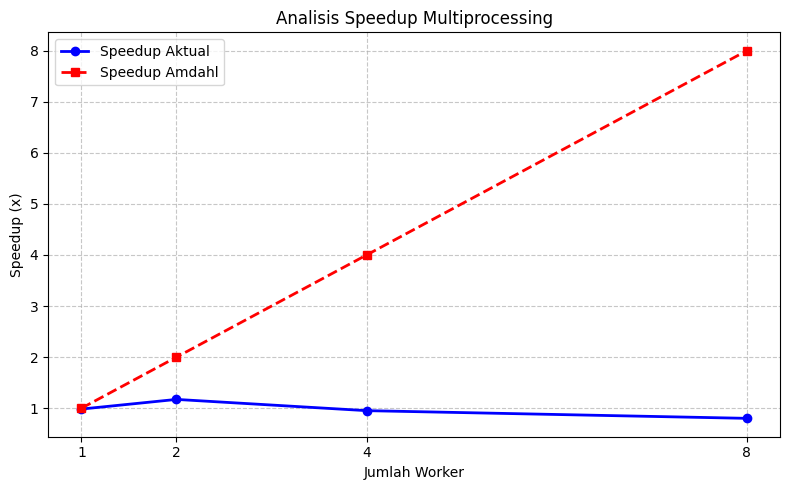

In [1]:
import multiprocessing as mp
import time
import matplotlib.pyplot as plt
import os

# Fungsi menghitung bilangan prima
def hitung_prima(n):
    primes = []

    for num in range(2, n):
        is_prime = True

        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break

        if is_prime:
            primes.append(num)

    return len(primes)


# 4 tugas independen
daftar_n = [80_000, 80_000, 80_000, 80_000]

# Baseline sekuensial
start = time.perf_counter()

hasil_sequential = [
    hitung_prima(n) for n in daftar_n
]

waktu_sequential = time.perf_counter() - start

print(f"Waktu Sequential: {waktu_sequential:.2f} detik")


# Eksperimen multiprocessing
daftar_worker = [1, 2, 4, 8]

hasil_waktu = []
hasil_speedup = []

for jumlah_worker in daftar_worker:
    start = time.perf_counter()

    with mp.get_context('fork').Pool(
        processes=jumlah_worker
    ) as pool:
        hasil_paralel = pool.map(hitung_prima, daftar_n)

    waktu_paralel = time.perf_counter() - start
    speedup = waktu_sequential / waktu_paralel

    hasil_waktu.append(waktu_paralel)
    hasil_speedup.append(speedup)

    print(f"\nWorker: {jumlah_worker}")
    print(f"Hasil: {hasil_paralel}")
    print(f"Waktu: {waktu_paralel:.2f} detik")
    print(f"Speedup: {speedup:.2f}x")


# Hukum Amdahl
P = 1.0

speedup_amdahl = [
    1 / ((1 - P) + P / n)
    for n in daftar_worker
]


# Grafik perbandingan
plt.figure(figsize=(8, 5))

plt.plot(
    daftar_worker,
    hasil_speedup,
    marker='o',
    color='b',
    linewidth=2,
    label='Speedup Aktual'
)

plt.plot(
    daftar_worker,
    speedup_amdahl,
    marker='s',
    color='r',
    linestyle='--',
    linewidth=2,
    label='Speedup Amdahl'
)

plt.title("Analisis Speedup Multiprocessing")
plt.xlabel("Jumlah Worker")
plt.ylabel("Speedup (x)")

plt.xticks(daftar_worker)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

Speedup aktual mungkin tidak sama dengan speedup teoritis karena beberapa faktor. Pertama, jumlah core fisik komputer terbatas sehingga penambahan worker tidak selalu meningkatkan kecepatan. Kedua, pembuatan dan pengelolaan proses multiprocessing membutuhkan waktu tambahan (overhead). Ketiga, proses lain yang berjalan bersamaan dapat menggunakan sumber daya CPU sehingga mengurangi kinerja eksperimen.

Selain itu, eksperimen ini hanya memiliki empat tugas independen. Ketika jumlah worker ditingkatkan menjadi delapan, sebagian worker tidak mendapatkan tugas sehingga penambahan worker tidak memberikan peningkatan kecepatan yang sebanding.

Dapat disimpulkan bahwa Hukum Amdahl menggambarkan batas percepatan teoritis, sedangkan speedup aktual dipengaruhi oleh kondisi perangkat keras, overhead proses, jumlah tugas, dan beban kerja komputer. Nilai speedup aktual baru dapat disimpulkan setelah eksperimen dijalankan.

2. Shared Memory vs Message Passing

a. Menggunakan Queue

In [2]:
import multiprocessing as mp
import numpy as np
import time

JUMLAH_PROSES = 4
JUMLAH_ANGKA = 1_000_000

# Fungsi untuk metode Queue
def worker_queue(data, queue):
    subtotal = np.sum(data)
    queue.put(float(subtotal))


# Fungsi untuk metode Value
def worker_value(data, shared_value, lock):
    subtotal = np.sum(data)

    with lock:
        shared_value.value += float(subtotal)


if __name__ == "__main__":

    # Membuat data acak
    rng = np.random.default_rng(42)

    data = [
        rng.random(JUMLAH_ANGKA)
        for _ in range(JUMLAH_PROSES)
    ]

    ctx = mp.get_context("fork")

    # A. MESSAGE PASSING (QUEUE)

    queue = ctx.Queue()
    proses = []

    start = time.perf_counter()

    for i in range(JUMLAH_PROSES):
        p = ctx.Process(
            target=worker_queue,
            args=(data[i], queue)
        )
        proses.append(p)
        p.start()

    hasil_queue = sum(
        queue.get()
        for _ in range(JUMLAH_PROSES)
    )

    for p in proses:
        p.join()

    waktu_queue = time.perf_counter() - start

    print("=== MESSAGE PASSING (QUEUE) ===")
    print(f"Total: {hasil_queue:.2f}")
    print(f"Waktu: {waktu_queue:.4f} detik")

    queue.close()
    queue.join_thread()

=== MESSAGE PASSING (QUEUE) ===
Total: 1999439.12
Waktu: 0.0524 detik


b. Menggunakan Value


=== SHARED MEMORY (VALUE) ===
Total: 1999439.12
Waktu: 0.0364 detik

=== PERBANDINGAN ===
Queue : 0.0524 detik
Value : 0.0364 detik


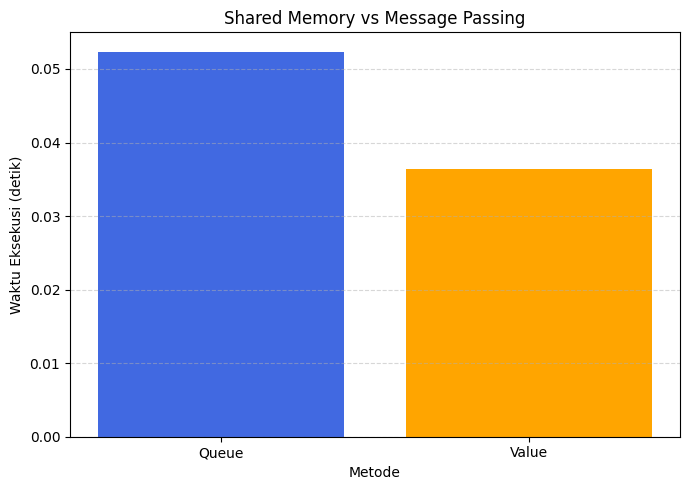

In [3]:

    shared_value = ctx.Value('d', 0.0)
    lock = ctx.Lock()
    proses = []

    start = time.perf_counter()

    for i in range(JUMLAH_PROSES):
        p = ctx.Process(
            target=worker_value,
            args=(data[i], shared_value, lock)
        )
        proses.append(p)
        p.start()

    for p in proses:
        p.join()

    waktu_value = time.perf_counter() - start

    print("\n=== SHARED MEMORY (VALUE) ===")
    print(f"Total: {shared_value.value:.2f}")
    print(f"Waktu: {waktu_value:.4f} detik")

    # Perbandingan
    print("\n=== PERBANDINGAN ===")
    print(f"Queue : {waktu_queue:.4f} detik")
    print(f"Value : {waktu_value:.4f} detik")

    # Grafik
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 5))

    plt.bar(
        ["Queue", "Value"],
        [waktu_queue, waktu_value],
        color=["royalblue", "orange"]
    )

    plt.title("Shared Memory vs Message Passing")
    plt.xlabel("Metode")
    plt.ylabel("Waktu Eksekusi (detik)")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

Kedua metode menghasilkan total yang sama atau sangat mendekati karena menggunakan data acak yang identik. Perbedaan kecil dapat muncul akibat urutan penjumlahan bilangan pecahan.

Pada metode Queue, setiap proses mengirim subtotal ke proses utama. Sementara itu, metode Value menggunakan memori bersama sehingga tidak perlu mengirim subtotal melalui Queue, tetapi membutuhkan Lock untuk mencegah race condition.

Metode Value berpotensi lebih cepat karena hanya memperbarui satu nilai bersama. Namun, hasil sebenarnya bergantung pada overhead komunikasi, sinkronisasi, dan kondisi komputer. Bandingkan waktu yang ditampilkan setelah program dijalankan.

3. Producer - Consumer Antar-Proses

=== MULTIPROCESSING ===
Hasil: [7837, 7837, 7837, 7837, 7837, 7837, 7837, 7837]
Waktu: 1.3959 detik

=== THREADING ===
Hasil: [7837, 7837, 7837, 7837, 7837, 7837, 7837, 7837]
Waktu: 0.9966 detik

=== PERBANDINGAN ===
Multiprocessing: 1.3959 detik
Threading      : 0.9966 detik
Rasio waktu Threading/Multiprocessing: 0.71x


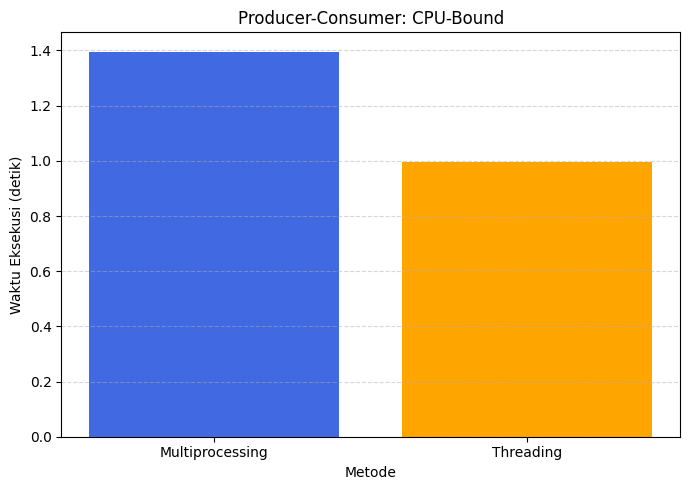

In [4]:
import multiprocessing as mp
import threading
import queue
import time
import matplotlib.pyplot as plt

# Fungsi menghitung bilangan prima
def hitung_prima(n):
    jumlah = 0

    for num in range(2, n):
        is_prime = True

        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break

        if is_prime:
            jumlah += 1

    return jumlah


# Producer
def producer(q, daftar_tugas, jumlah_consumer):
    for tugas in daftar_tugas:
        q.put(tugas)

    # Sinyal bahwa semua tugas telah dikirim
    for _ in range(jumlah_consumer):
        q.put(None)


# Consumer
def consumer(q, hasil):
    while True:
        tugas = q.get()

        if tugas is None:
            break

        jumlah_prima = hitung_prima(tugas)
        hasil.put(jumlah_prima)


if __name__ == "__main__":

    daftar_tugas = [80_000] * 8
    jumlah_consumer = 4

    # A. MULTIPROCESSING

    ctx = mp.get_context("fork")

    q = ctx.Queue()
    hasil = ctx.Queue()

    start = time.perf_counter()

    p_produser = ctx.Process(
        target=producer,
        args=(q, daftar_tugas, jumlah_consumer)
    )

    consumers = [
        ctx.Process(
            target=consumer,
            args=(q, hasil)
        )
        for _ in range(jumlah_consumer)
    ]

    for p in consumers:
        p.start()

    p_produser.start()

    hasil_mp = [
        hasil.get()
        for _ in daftar_tugas
    ]

    p_produser.join()

    for p in consumers:
        p.join()

    waktu_mp = time.perf_counter() - start

    print("=== MULTIPROCESSING ===")
    print("Hasil:", hasil_mp)
    print(f"Waktu: {waktu_mp:.4f} detik")

    q.close()
    hasil.close()

    # B. THREADING

    q_thread = queue.Queue()
    hasil_thread = queue.Queue()

    start = time.perf_counter()

    t_produser = threading.Thread(
        target=producer,
        args=(q_thread, daftar_tugas, jumlah_consumer)
    )

    threads = [
        threading.Thread(
            target=consumer,
            args=(q_thread, hasil_thread)
        )
        for _ in range(jumlah_consumer)
    ]

    for t in threads:
        t.start()

    t_produser.start()

    hasil_th = [
        hasil_thread.get()
        for _ in daftar_tugas
    ]

    t_produser.join()

    for t in threads:
        t.join()

    waktu_th = time.perf_counter() - start

    print("\n=== THREADING ===")
    print("Hasil:", hasil_th)
    print(f"Waktu: {waktu_th:.4f} detik")

    # PERBANDINGAN

    print("\n=== PERBANDINGAN ===")
    print(f"Multiprocessing: {waktu_mp:.4f} detik")
    print(f"Threading      : {waktu_th:.4f} detik")

    print(
        f"Rasio waktu Threading/Multiprocessing: "
        f"{waktu_th / waktu_mp:.2f}x"
    )

    # GRAFIK

    plt.figure(figsize=(7, 5))

    plt.bar(
        ["Multiprocessing", "Threading"],
        [waktu_mp, waktu_th],
        color=["royalblue", "orange"]
    )

    plt.title("Producer-Consumer: CPU-Bound")
    plt.xlabel("Metode")
    plt.ylabel("Waktu Eksekusi (detik)")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

Apakah struktur kode banyak berubah?

Struktur dasar producer-consumer tidak banyak berubah. Producer tetap memasukkan tugas ke Queue dan consumer tetap mengambil serta mengerjakan tugas tersebut. Perbedaan utamanya terletak pada penggunaan multiprocessing.Process dan multiprocessing.Queue sebagai pengganti threading.Thread dan queue.Queue.

Bagaimana perbedaan performanya?

Pada pekerjaan CPU-bound, multiprocessing dapat memanfaatkan beberapa core CPU secara bersamaan. Sebaliknya, pada CPython standar dengan GIL, threading tidak dapat menjalankan beberapa perhitungan Python sekaligus secara paralel.

Meskipun demikian, multiprocessing membutuhkan overhead pembuatan proses dan komunikasi antarproses. Hasil pengukuran dapat berbeda tergantung jumlah core CPU dan beban kerja. Gunakan angka dari hasil eksekusi program untuk menentukan metode mana yang lebih cepat dalam eksperimenmu.

4. Refleksi singkat

Saya akan memilih Manager() ketika membuat aplikasi yang membutuhkan berbagi struktur data kompleks antarproses, seperti dictionary atau list pada sistem pengolahan pesanan. Manager mempermudah pengelolaan data bersama tanpa harus mengatur memori secara manual, tetapi memiliki overhead komunikasi yang dapat memperlambat eksekusi.

Sebaliknya, saya akan memilih Value atau Array untuk aplikasi yang membutuhkan perhitungan numerik berulang, seperti penghitung transaksi atau pengolahan data sensor. Keduanya menggunakan shared memory sehingga lebih efisien untuk berbagi data numerik sederhana.

Berdasarkan perbandingan tersebut, Manager lebih sesuai ketika kemudahan pemrograman dan fleksibilitas struktur data menjadi prioritas. Sementara itu, Value dan Array lebih sesuai ketika performa menjadi kebutuhan utama, meskipun penggunaannya memerlukan pengaturan sinkronisasi seperti Lock untuk mencegah race condition.